In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.impute import KNNImputer
from sklearn.preprocessing import RobustScaler
from sklearn.model_selection import train_test_split
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
from warnings import simplefilter
# ignore all future warnings
simplefilter(action='ignore', category=FutureWarning)

In [3]:
data=pd.read_csv("corporate_ratings_for_candidates_new (1).csv")
data.head()

,Rating,Name,Rating Agency Name,Date,Sector,currentRatio,quickRatio,cashRatio,daysOfSalesOutstanding,netProfitMargin,pretaxProfitMargin,grossProfitMargin,operatingProfitMargin,returnOnAssets,returnOnCapitalEmployed,returnOnEquity,assetTurnover,fixedAssetTurnover,debtEquityRatio,debtRatio,effectiveTaxRate,freeCashFlowOperatingCashFlowRatio,freeCashFlowPerShare,cashPerShare,companyEquityMultiplier,ebitPerRevenue,enterpriseValueMultiple,operatingCashFlowPerShare,operatingCashFlowSalesRatio,payablesTurnover
0,AA,Company 44,Rating agency 5,8/16/2005,Energy,0.885237,0.550896,0.143469,36.817520,0.094024,0.188131,1.009959,0.190213,0.143913,0.504413,0.160121,1.541119,3.390181,1.912761,1.769042,0.000000,0.547603,16.926785,10.433176,1.088336,0.190117,1.274560,31.329441,0.153534,0.00000
1,BB,Company 135,Rating agency 3,4/28/2009,Basic Industries,2.052828,0.511835,0.260385,0.000000,0.094189,0.132762,0.121490,0.137469,0.130518,0.223959,0.434201,1.388712,3.344361,2.253043,0.686885,0.284569,0.998442,6.286350,12.016261,3.298016,0.133657,0.959817,6.333349,0.032843,13.69679
2,CCC,Company 118,Rating agency 3,8/3/2010,Health Care,1.340032,1.090468,0.235971,45.137229,0.121169,0.017074,1.004473,0.069101,0.131112,0.023242,0.635298,1.093698,2.137543,3.829918,0.795181,-6.228259,1.001744,0.965080,NaN,4.811879,0.017046,15.625364,0.973799,0.051749,0.00000
3,CCC,Company 118,Rating agency 3,8/3/2010,Health Care,1.340032,1.090468,0.235971,45.137229,0.121169,0.017074,1.004473,0.069101,0.131112,0.023242,0.635298,1.093698,2.137543,3.829918,0.795181,-6.228259,1.001744,0.965080,NaN,4.811879,0.017046,15.625364,0.973799,0.051749,0.00000
4,BBB,Company 309,Rating agency 3,8/31/2010,Energy,1.393784,0.439914,0.027211,21.435616,0.199471,0.201420,0.990008,0.202475,0.083609,0.090809,0.211589,0.418874,0.487557,1.518487,0.606278,0.004395,-0.524239,-2.024697,NaN,2.550233,0.200256,11.760623,3.911740,0.274350,0.00000


In [4]:
data.shape

(2434, 30)

In [5]:
data.duplicated().sum()

405

In [6]:
data.drop_duplicates(inplace=True)

In [7]:
data.shape

(2029, 30)

In [8]:
# Calculate percentage of missing values per column
missing_percent = round((data.isnull().sum() / len(data)) * 100,2)

# Filter only columns with missing values and sort
missing_percent = missing_percent[missing_percent > 0].sort_values(ascending=False)

# Display
missing_percent.to_frame(name='Missing Percentage (%)')

,Missing Percentage (%)
cashPerShare,54.95
returnOnEquity,16.76
companyEquityMultiplier,4.98


In [9]:
data.describe()

,currentRatio,quickRatio,cashRatio,daysOfSalesOutstanding,netProfitMargin,pretaxProfitMargin,grossProfitMargin,operatingProfitMargin,returnOnAssets,returnOnCapitalEmployed,returnOnEquity,assetTurnover,fixedAssetTurnover,debtEquityRatio,debtRatio,effectiveTaxRate,freeCashFlowOperatingCashFlowRatio,freeCashFlowPerShare,cashPerShare,companyEquityMultiplier,ebitPerRevenue,enterpriseValueMultiple,operatingCashFlowPerShare,operatingCashFlowSalesRatio,payablesTurnover
count,2029.000000,2029.000000,2029.000000,2.029000e+03,2029.000000,2029.000000,2.029000e+03,2029.000000,2029.000000,2029.000000,1689.000000,2.029000e+03,2.029000e+03,2029.000000,2029.000000,2029.000000,2029.000000,2.029000e+03,9.140000e+02,1.928000e+03,2029.000000,2.029000e+03,2.029000e+03,2029.000000,2029.000000
mean,485.850319,440.850292,50.476393,1.373381e+04,38.927421,44.663401,4.973655e+02,44.631653,-11.825139,-41.965186,224.482631,4.022057e+03,7.619826e+03,329.935514,199.220731,56.622791,230.157231,5.616657e+03,4.086796e+03,8.638583e+02,44.765728,3.985377e+03,7.732913e+03,37.447357,38.111232
std,21725.516582,19738.297900,2243.598332,6.035765e+05,1740.937272,1992.430598,2.238112e+04,1984.024560,1649.247857,2742.330421,5283.636011,9.728296e+04,1.893109e+05,14757.163343,8943.986272,2532.561629,10348.870587,1.480522e+05,9.108577e+04,3.784396e+04,1996.680921,1.773391e+05,1.865025e+05,1621.912067,761.964608
min,-0.941249,-1.874556,-0.193124,-8.080899e+02,-102.351481,-124.429111,-1.467401e+01,-124.202352,-40466.620910,-86500.736400,-0.000046,-9.192779e+00,-2.670543e+01,-2573.889178,0.000000,-100.254091,-120.974675,-4.887245e+03,-6.793396e+00,-2.574404e+03,-124.157521,-3.782686e+03,-1.183701e+04,-4.419470,-77.328977
25%,1.074929,0.604653,0.130954,2.291911e+01,0.020959,0.025688,2.328685e-01,0.044712,0.019048,0.028128,0.091651,3.889270e-01,1.029018e+00,1.046653,0.535515,0.149127,0.270108,4.125437e-01,1.656380e+00,2.044834e+00,0.028012,6.231696e+00,2.344920e+00,0.073829,2.205180
50%,1.493202,0.981857,0.297916,4.240764e+01,0.065125,0.084895,4.148720e-01,0.108442,0.045760,0.074467,0.142957,6.990604e-01,3.820450e+00,1.655386,0.640980,0.300484,0.644344,2.140183e+00,3.769587e+00,2.647813e+00,0.087341,9.312173e+00,4.364080e+00,0.133186,5.764466
75%,2.171763,1.452663,0.626713,5.918856e+01,0.114920,0.144972,8.521692e-01,0.176616,0.077453,0.135625,0.224980,1.102398e+00,8.552377e+00,2.639010,0.749933,0.371127,0.839900,4.255850e+00,8.237431e+00,3.613532e+00,0.149529,1.293622e+01,7.322765e+00,0.241324,9.482282
max,978614.850000,889101.646000,101062.130000,2.718734e+07,78419.316000,89747.404000,1.008145e+06,89368.406000,52330.604000,64393.027000,142009.304300,2.574963e+06,5.162884e+06,664718.440000,402877.358000,114077.166000,466159.277000,5.714346e+06,2.526938e+06,1.661690e+06,89938.861000,7.988148e+06,6.498186e+06,73054.322000,20495.754880


In [10]:
data.isnull().sum()

Rating                                   0
Name                                     0
Rating Agency Name                       0
Date                                     0
Sector                                   0
currentRatio                             0
quickRatio                               0
cashRatio                                0
daysOfSalesOutstanding                   0
netProfitMargin                          0
pretaxProfitMargin                       0
grossProfitMargin                        0
operatingProfitMargin                    0
returnOnAssets                           0
returnOnCapitalEmployed                  0
returnOnEquity                         340
assetTurnover                            0
fixedAssetTurnover                       0
debtEquityRatio                          0
debtRatio                                0
effectiveTaxRate                         0
freeCashFlowOperatingCashFlowRatio       0
freeCashFlowPerShare                     0
cashPerShar

Treatment of Outlier data as Missing values using Imputation

In [11]:
def apply_tomi(df, numeric_cols, method='knn', n_neighbors=5):
    df_clean = df.copy()
    
    for col in numeric_cols:
        # Step 1: Detect outliers using IQR
        Q1 = df_clean[col].quantile(0.25)
        Q3 = df_clean[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR

        # Step 2: Replace outliers with NaN
        outliers = (df_clean[col] < lower_bound) | (df_clean[col] > upper_bound)
        df_clean.loc[outliers, col] = np.nan

    # Step 3: Impute missing values
    if method == 'knn':
        imputer = KNNImputer(n_neighbors=n_neighbors)
        df_clean[numeric_cols] = imputer.fit_transform(df_clean[numeric_cols])
    elif method == 'median':
        df_clean[numeric_cols] = df_clean[numeric_cols].fillna(df_clean[numeric_cols].median())

    return df_clean

In [12]:
# Select numeric features
numeric_cols = data.select_dtypes(include='float64').columns.tolist()

# Apply TOMI with KNN
df_clean = apply_tomi(data, numeric_cols, method='knn', n_neighbors=5)


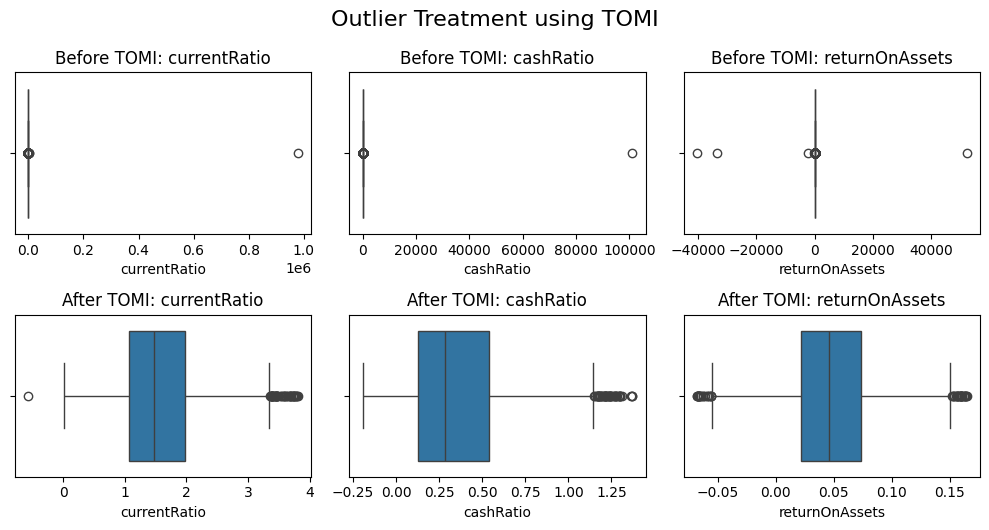

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

# Select features where outliers were present
features_to_plot = ['currentRatio', 'cashRatio', 'returnOnAssets']

# Create subplots
plt.figure(figsize=(10, 5))

for i, col in enumerate(features_to_plot):
    plt.subplot(2, len(features_to_plot), i + 1)
    sns.boxplot(x=data[col])
    plt.title(f'Before TOMI: {col}')
    plt.tight_layout()

    plt.subplot(2, len(features_to_plot), i + 1 + len(features_to_plot))
    sns.boxplot(x=df_clean[col])
    plt.title(f'After TOMI: {col}')
    plt.tight_layout()

plt.suptitle("Outlier Treatment using TOMI", fontsize=16, y=1.05)
plt.show()


In [14]:
df_clean.head()

,Rating,Name,Rating Agency Name,Date,Sector,currentRatio,quickRatio,cashRatio,daysOfSalesOutstanding,netProfitMargin,pretaxProfitMargin,grossProfitMargin,operatingProfitMargin,returnOnAssets,returnOnCapitalEmployed,returnOnEquity,assetTurnover,fixedAssetTurnover,debtEquityRatio,debtRatio,effectiveTaxRate,freeCashFlowOperatingCashFlowRatio,freeCashFlowPerShare,cashPerShare,companyEquityMultiplier,ebitPerRevenue,enterpriseValueMultiple,operatingCashFlowPerShare,operatingCashFlowSalesRatio,payablesTurnover
0,AA,Company 44,Rating agency 5,8/16/2005,Energy,0.885237,0.550896,0.143469,36.817520,0.094024,0.188131,1.009959,0.190213,0.143913,0.184689,0.160121,1.541119,3.390181,1.912761,0.631335,0.000000,0.547603,0.049198,10.433176,1.088336,0.190117,1.274560,3.093736,0.153534,0.000000
1,BB,Company 135,Rating agency 3,4/28/2009,Basic Industries,2.052828,0.511835,0.260385,0.000000,0.094189,0.132762,0.121490,0.137469,0.130518,0.223959,0.140879,1.388712,3.344361,2.253043,0.686885,0.284569,0.998442,6.286350,12.016261,3.298016,0.133657,0.959817,6.333349,0.032843,13.696790
2,CCC,Company 118,Rating agency 3,8/3/2010,Health Care,1.340032,1.090468,0.235971,45.137229,0.121169,0.017074,1.004473,0.069101,0.131112,0.023242,0.045285,1.093698,2.137543,3.829918,0.795181,0.309316,1.001744,0.965080,3.277277,4.811879,0.017046,15.625364,0.973799,0.051749,0.000000
4,BBB,Company 309,Rating agency 3,8/31/2010,Energy,1.393784,0.439914,0.027211,21.435616,0.199471,0.201420,0.990008,0.202475,0.083609,0.090809,0.211589,0.418874,0.487557,1.518487,0.606278,0.004395,-0.524239,-2.024697,4.779136,2.550233,0.200256,11.760623,3.911740,0.274350,0.000000
5,BBB,Company 56,Rating agency 3,9/30/2010,Miscellaneous,1.187288,0.514920,0.190278,53.102900,0.054140,0.097922,0.508211,0.099159,0.034475,0.089895,0.236613,0.639344,12.741720,1.384159,1.016996,0.386876,0.881115,4.040228,2.519301,2.403030,0.099138,10.459175,4.615069,0.176765,0.077434


In [15]:
df_clean.isnull().sum()

Rating                                0
Name                                  0
Rating Agency Name                    0
Date                                  0
Sector                                0
currentRatio                          0
quickRatio                            0
cashRatio                             0
daysOfSalesOutstanding                0
netProfitMargin                       0
pretaxProfitMargin                    0
grossProfitMargin                     0
operatingProfitMargin                 0
returnOnAssets                        0
returnOnCapitalEmployed               0
returnOnEquity                        0
assetTurnover                         0
fixedAssetTurnover                    0
debtEquityRatio                       0
debtRatio                             0
effectiveTaxRate                      0
freeCashFlowOperatingCashFlowRatio    0
freeCashFlowPerShare                  0
cashPerShare                          0
companyEquityMultiplier               0


In [16]:
df_clean.describe()

,currentRatio,quickRatio,cashRatio,daysOfSalesOutstanding,netProfitMargin,pretaxProfitMargin,grossProfitMargin,operatingProfitMargin,returnOnAssets,returnOnCapitalEmployed,returnOnEquity,assetTurnover,fixedAssetTurnover,debtEquityRatio,debtRatio,effectiveTaxRate,freeCashFlowOperatingCashFlowRatio,freeCashFlowPerShare,cashPerShare,companyEquityMultiplier,ebitPerRevenue,enterpriseValueMultiple,operatingCashFlowPerShare,operatingCashFlowSalesRatio,payablesTurnover
count,2029.000000,2029.000000,2029.000000,2029.000000,2029.000000,2029.000000,2029.000000,2029.000000,2029.000000,2029.000000,2029.000000,2029.000000,2029.000000,2029.000000,2029.000000,2029.000000,2029.000000,2029.000000,2029.000000,2029.000000,2029.000000,2029.000000,2029.000000,2029.000000,2029.000000
mean,1.590187,1.007968,0.366366,40.006941,0.071683,0.088670,0.512874,0.116933,0.047721,0.078686,0.141513,0.756031,4.764868,1.828582,0.644547,0.267488,0.556180,2.266737,4.430384,2.826731,0.093128,9.315136,4.552027,0.151664,5.897127
std,0.716021,0.549017,0.301250,24.953701,0.064880,0.079705,0.332908,0.089670,0.042630,0.075449,0.080050,0.474939,4.257760,0.954650,0.155105,0.152199,0.382677,2.644528,3.086137,0.920038,0.082339,4.586062,3.149286,0.106165,4.700499
min,-0.561963,-0.605174,-0.193124,0.000000,-0.119796,-0.152495,-0.583605,-0.151139,-0.068008,-0.132996,-0.000046,-0.058478,-0.023782,-1.005147,0.240851,-0.182093,-0.580118,-5.343165,-6.793396,-0.098755,-0.153577,-3.642940,-4.861714,-0.168286,-5.585685
25%,1.069441,0.596478,0.130582,22.632438,0.028939,0.035015,0.235474,0.053793,0.021870,0.031084,0.086928,0.384567,1.000859,1.133934,0.537370,0.184324,0.355744,0.497760,2.372007,2.151464,0.036961,6.262339,2.278547,0.075269,2.107218
50%,1.474575,0.946691,0.285869,40.897149,0.067887,0.087172,0.415955,0.112264,0.045777,0.072427,0.128619,0.671353,3.646662,1.643101,0.637585,0.292397,0.653745,2.012036,3.845119,2.663834,0.090792,9.073628,4.067077,0.130533,5.415798
75%,1.981010,1.322421,0.537148,56.083309,0.108716,0.136250,0.852169,0.168095,0.073507,0.128262,0.185108,1.026476,7.481462,2.327579,0.739715,0.360643,0.832111,3.810009,5.761113,3.323539,0.140317,12.024254,6.402498,0.214348,8.609399
max,3.807490,2.706340,1.370136,113.150210,0.253183,0.323086,1.735232,0.374182,0.164524,0.292448,0.418348,2.167586,19.759661,5.021523,1.070781,0.703125,1.655290,9.966066,17.743185,5.960783,0.331459,22.983333,14.785505,0.491876,20.193160


In [17]:
df_clean.columns

Index(['Rating', 'Name', 'Rating Agency Name', 'Date', 'Sector',
       'currentRatio', 'quickRatio', 'cashRatio', 'daysOfSalesOutstanding',
       'netProfitMargin', 'pretaxProfitMargin', 'grossProfitMargin',
       'operatingProfitMargin', 'returnOnAssets', 'returnOnCapitalEmployed',
       'returnOnEquity', 'assetTurnover', 'fixedAssetTurnover',
       'debtEquityRatio', 'debtRatio', 'effectiveTaxRate',
       'freeCashFlowOperatingCashFlowRatio', 'freeCashFlowPerShare',
       'cashPerShare', 'companyEquityMultiplier', 'ebitPerRevenue',
       'enterpriseValueMultiple', 'operatingCashFlowPerShare',
       'operatingCashFlowSalesRatio', 'payablesTurnover'],
      dtype='object')

In [18]:
df_clean.to_csv("processed_data.csv")

### Exploratory Data Analysis (EDA)

In [19]:
#What is the proportion of each credit rating class? Is the data imbalanced?

df_clean['Rating'].value_counts()

Rating
BBB    671
BB     490
A      398
B      302
AA      89
CCC     64
AAA      7
CC       5
C        2
D        1
Name: count, dtype: int64

For the risker ratings like C and D are less number of data compared to the top ratings, so the data set is highly imbalanced

In [ ]:
# # Set style
# sns.set(style='whitegrid')
# plt.rcParams['figure.figsize'] = (8, 4)

# # Select numerical columns
# num_cols = df_clean.select_dtypes(include='float64').columns.tolist()

# # Plot histograms for numerical features
# for col in num_cols:
#     plt.figure()
#     sns.histplot(df_clean[col], kde=True, bins=30)
#     plt.title(f'Distribution of {col}')
#     plt.xlabel(col)
#     plt.ylabel('Frequency')
#     plt.tight_layout()
#     plt.show()

In [21]:
df_clean.columns

Index(['Rating', 'Name', 'Rating Agency Name', 'Date', 'Sector',
       'currentRatio', 'quickRatio', 'cashRatio', 'daysOfSalesOutstanding',
       'netProfitMargin', 'pretaxProfitMargin', 'grossProfitMargin',
       'operatingProfitMargin', 'returnOnAssets', 'returnOnCapitalEmployed',
       'returnOnEquity', 'assetTurnover', 'fixedAssetTurnover',
       'debtEquityRatio', 'debtRatio', 'effectiveTaxRate',
       'freeCashFlowOperatingCashFlowRatio', 'freeCashFlowPerShare',
       'cashPerShare', 'companyEquityMultiplier', 'ebitPerRevenue',
       'enterpriseValueMultiple', 'operatingCashFlowPerShare',
       'operatingCashFlowSalesRatio', 'payablesTurnover'],
      dtype='object')

- operatingCashFlowPerShare,operatingCashFlowSalesRatio,cashPerShare, are highy right skewed
- freeCashFlowOperatingCashFlowRatio,effectiveTaxRate are highly left skewed
- enterpriseValueMultiple,debtRatio are normaly distributed

Rating Distribution (Target):

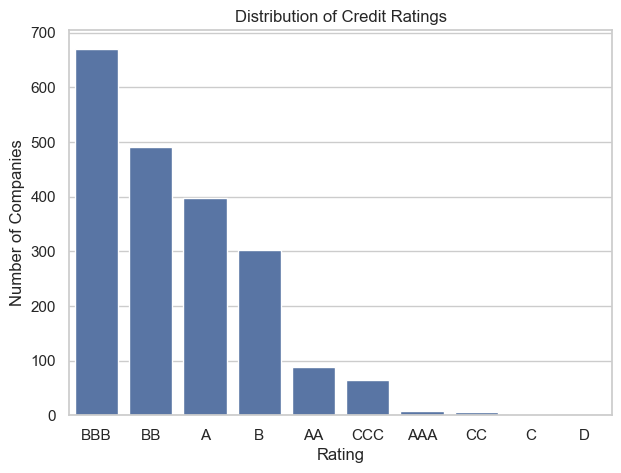

In [22]:
plt.figure(figsize=(7,5))
sns.countplot(x='Rating', data=df_clean, order=df_clean['Rating'].value_counts().index)
plt.title("Distribution of Credit Ratings")
plt.ylabel("Number of Companies")
plt.xlabel("Rating")
plt.show()

- The majority of companies are rated between BBB → B
- BBB dominates the dataset with ~670 entries — clearly the most common rating
- Very few companies are rated AAA, CC, and practically none for C or D
- Ratings are not balanced → this is class imbalance, and will impact model training

Sector Distribution:

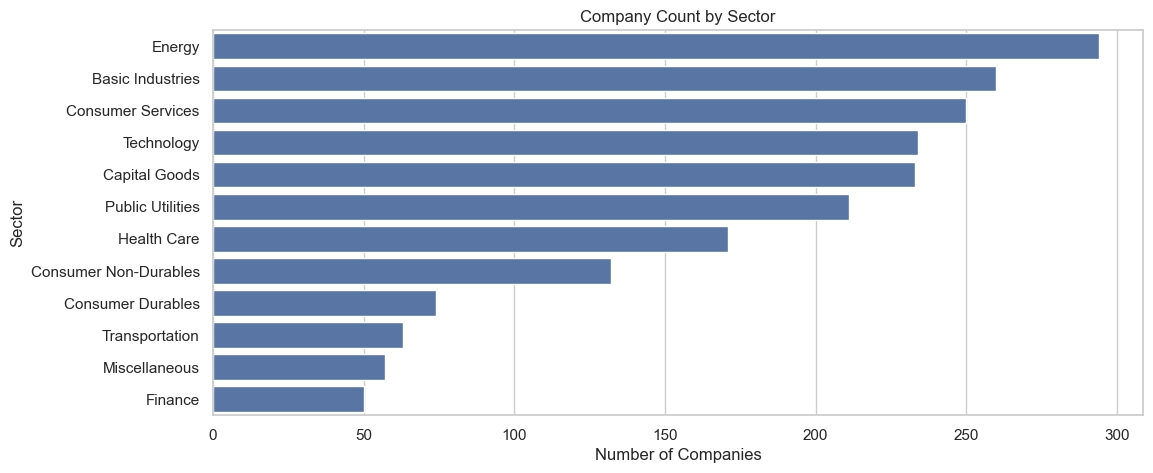

In [23]:
plt.figure(figsize=(12,5))
sns.countplot(y='Sector', data=df_clean, order=df_clean['Sector'].value_counts().index)
plt.title("Company Count by Sector")
plt.xlabel("Number of Companies")
plt.ylabel("Sector")
plt.show()

The top sectors by volume are:

- Energy (~290 companies)

- Basic Industries, Consumer Services, and Technology

Finance, Miscellaneous, and Transportation are the least represented sectors

Sector distribution is somewhat imbalanced, but not critically skewed

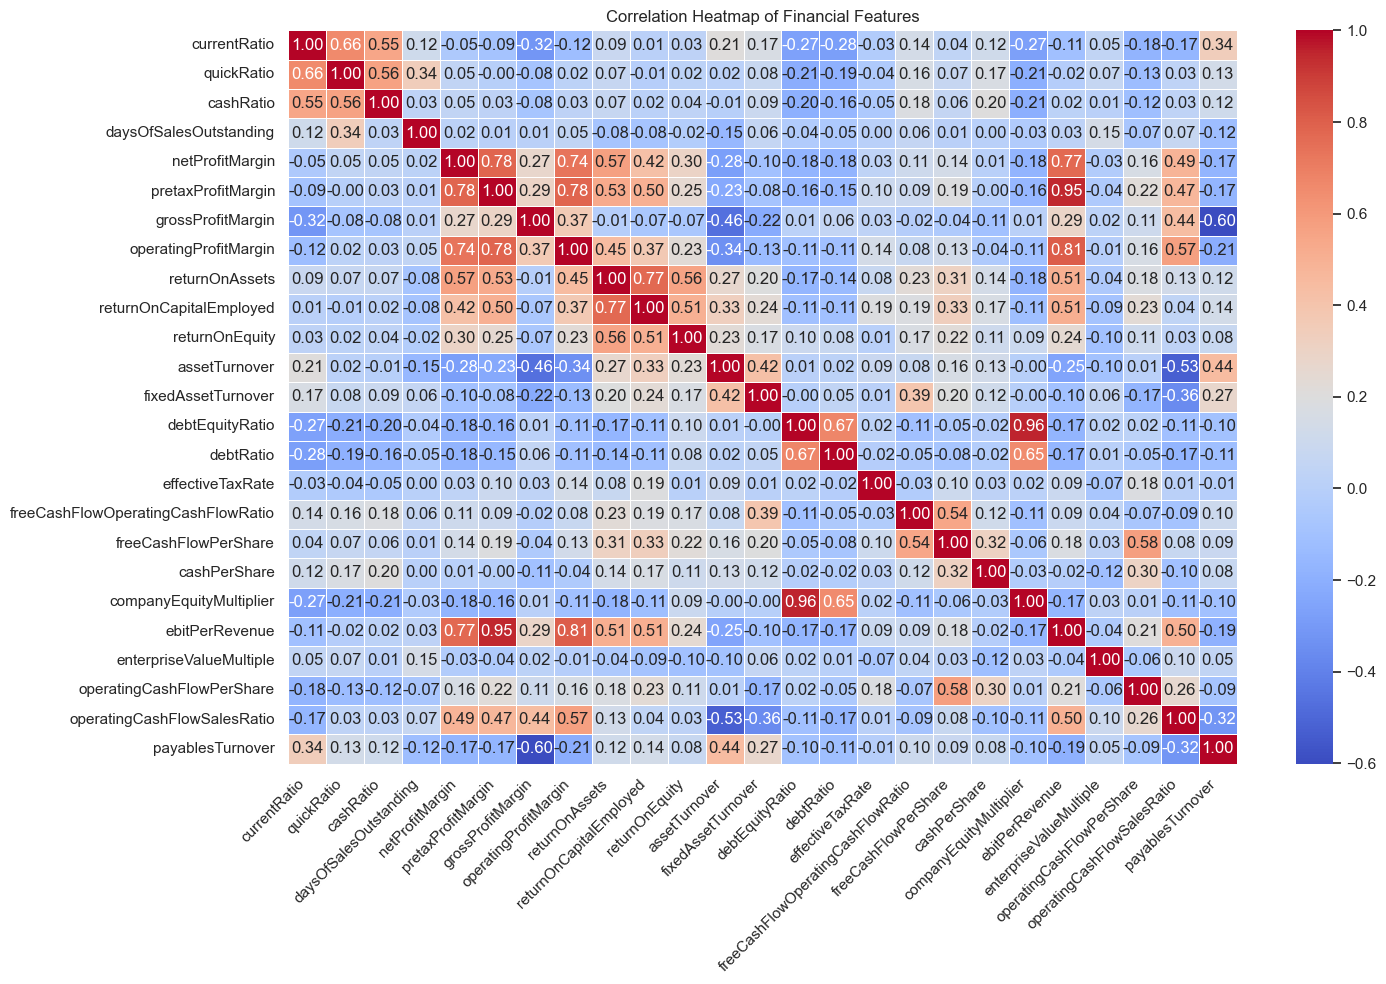

In [24]:
#Drop non-numeric or irrelevant columns
numeric_df = df_clean.select_dtypes(include=['float64', 'int64'])

# Compute the correlation matrix
corr_matrix = numeric_df.corr()

# Plot the heatmap
plt.figure(figsize=(15, 10))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title("Correlation Heatmap of Financial Features")
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

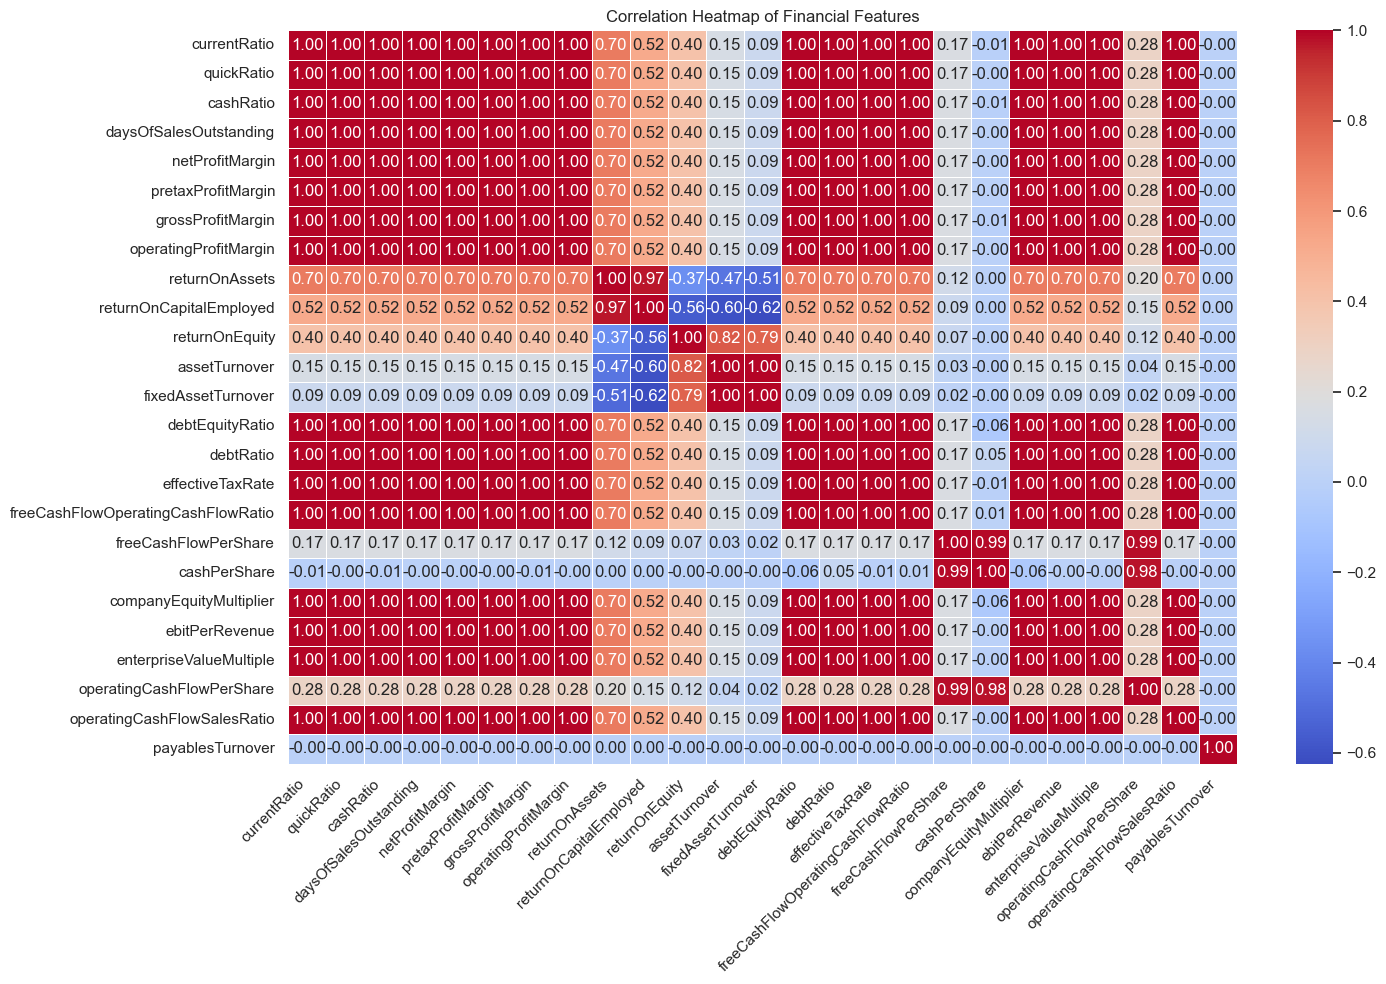

In [25]:
#Drop non-numeric or irrelevant columns
numeric_df = data.select_dtypes(include=['float64', 'int64'])

# Compute the correlation matrix
corr_matrix = numeric_df.corr()

# Plot the heatmap
plt.figure(figsize=(15, 10))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title("Correlation Heatmap of Financial Features")
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

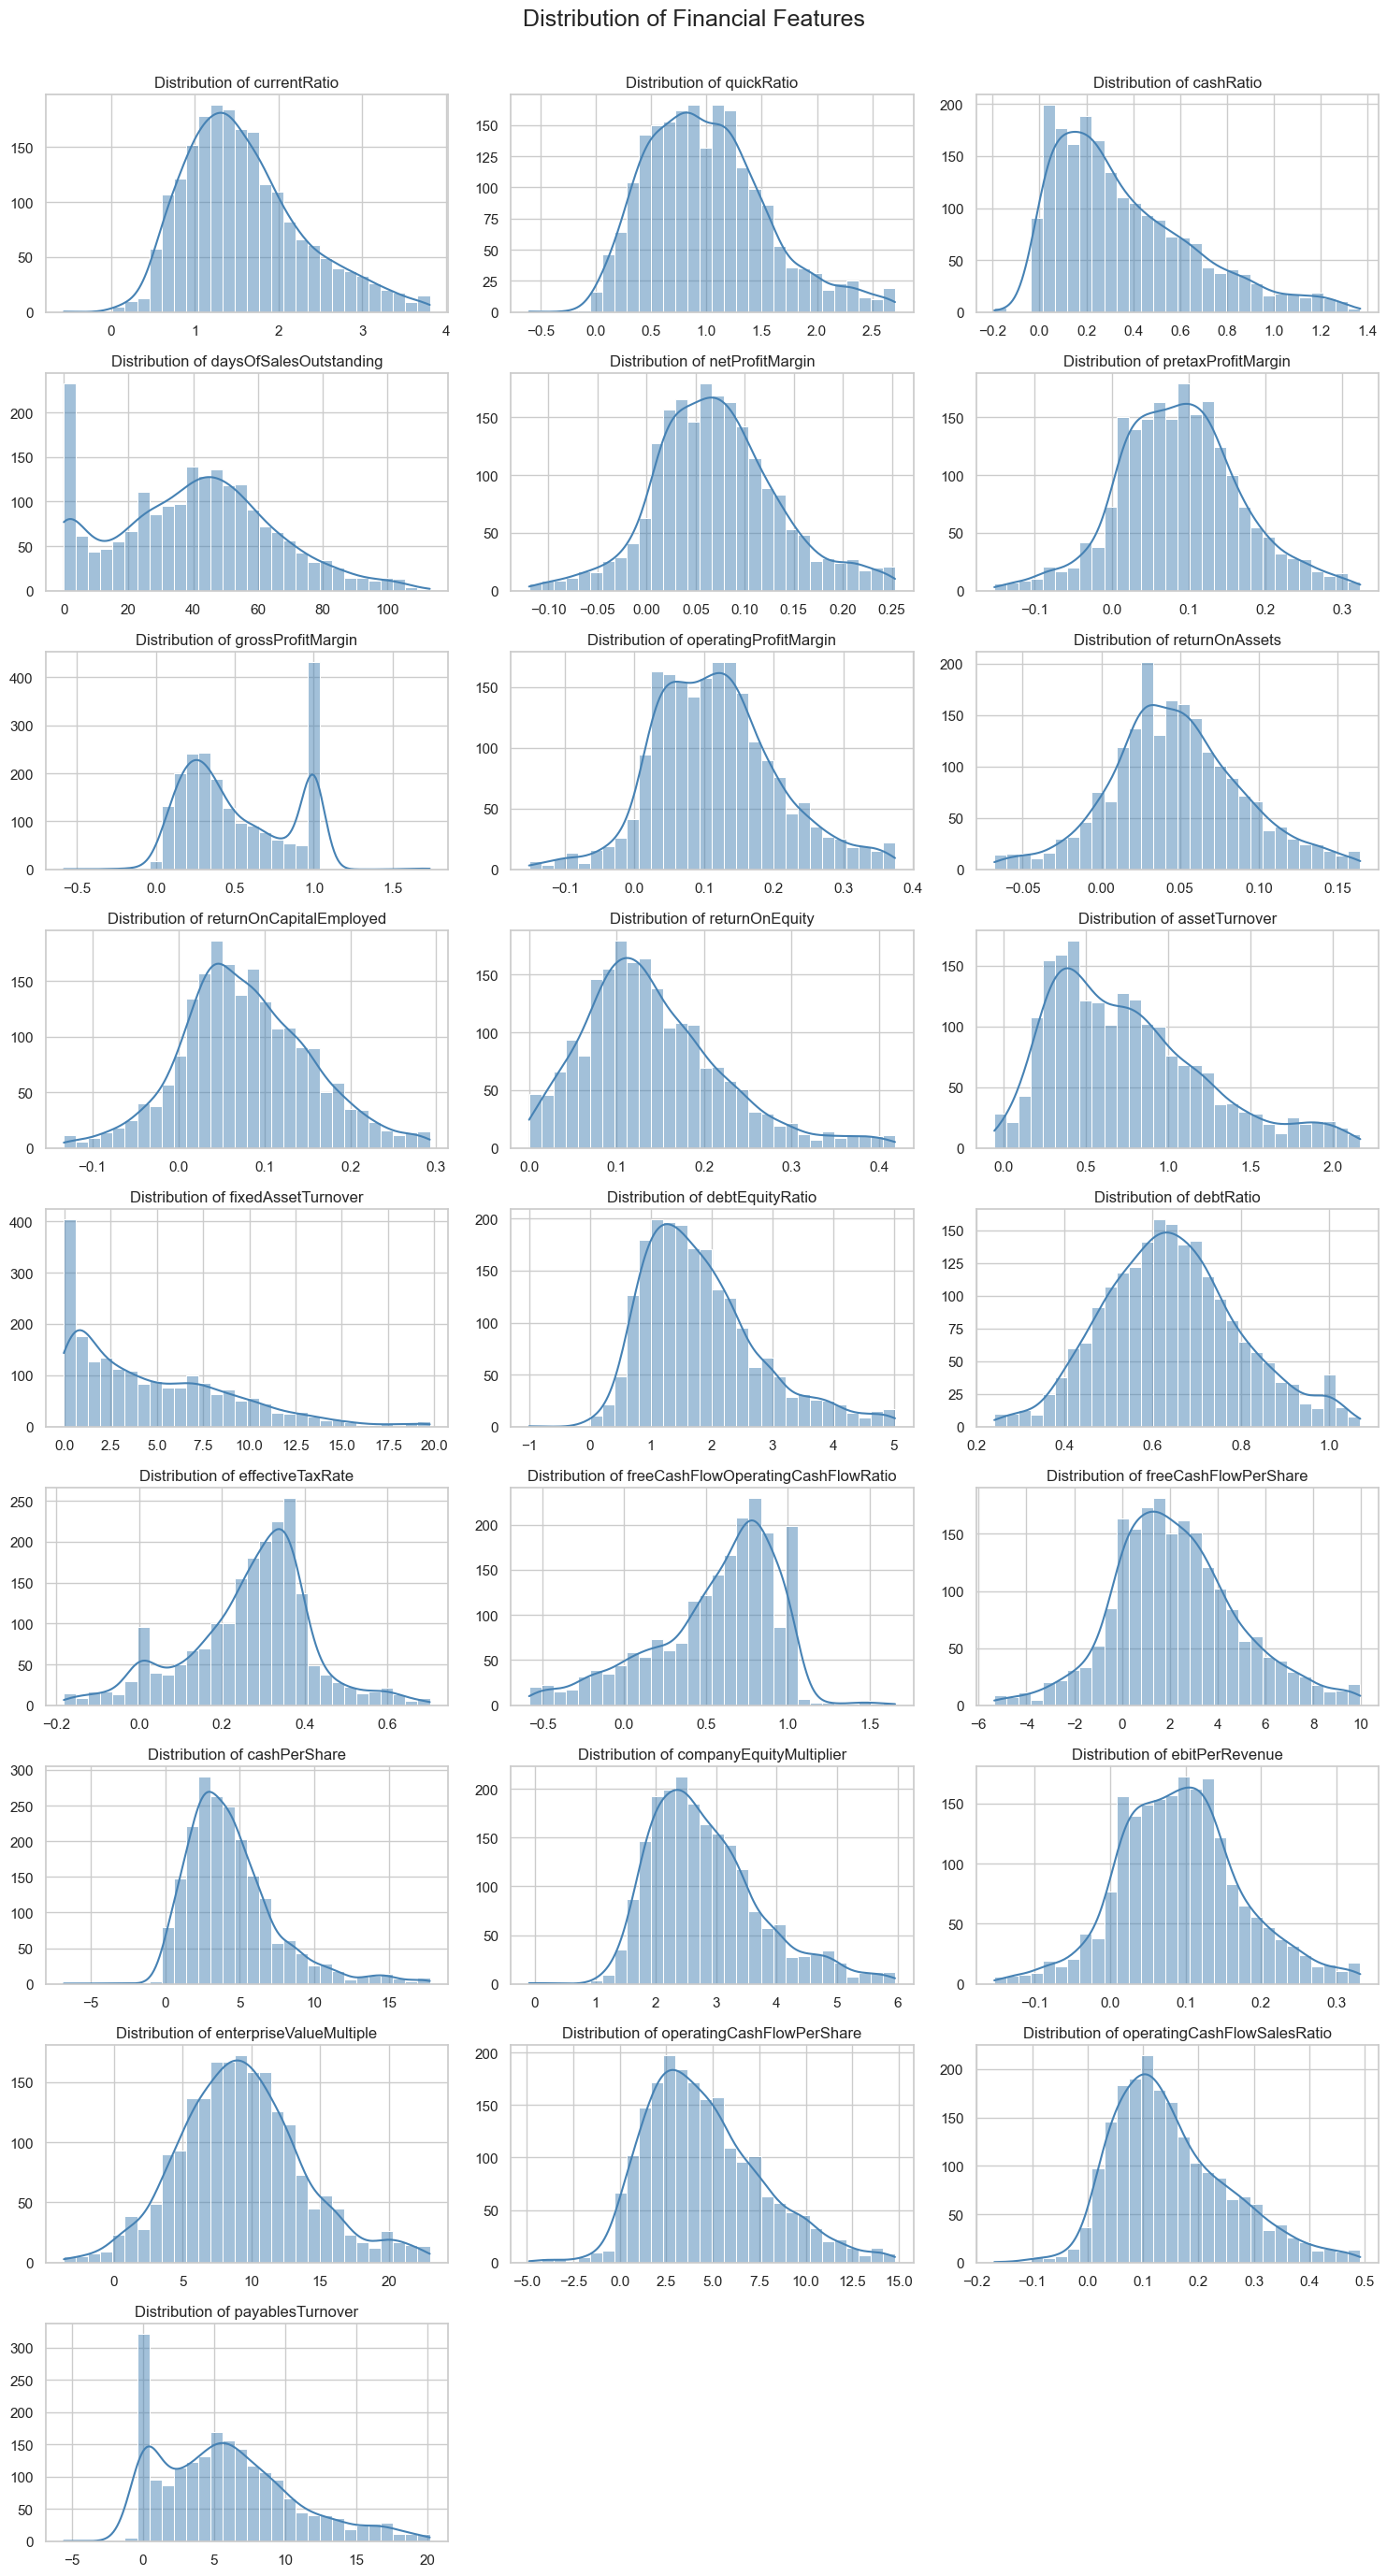

In [26]:

numeric_cols = df_clean.select_dtypes(include=['float64', 'int64']).columns

# Plot distributions
num_features = len(numeric_cols)
cols = 3  # number of columns in subplot grid
rows = (num_features // cols) + 1  # number of rows

plt.figure(figsize=(15, rows * 3))

for i, col in enumerate(numeric_cols, 1):
    plt.subplot(rows, cols, i)
    sns.histplot(df_clean[col], kde=True, bins=30, color='steelblue')
    plt.title(f'Distribution of {col}')
    plt.xlabel('')
    plt.ylabel('')

plt.tight_layout()
plt.suptitle("Distribution of Financial Features", fontsize=18, y=1.02)
plt.show()

Bivariate Analysis

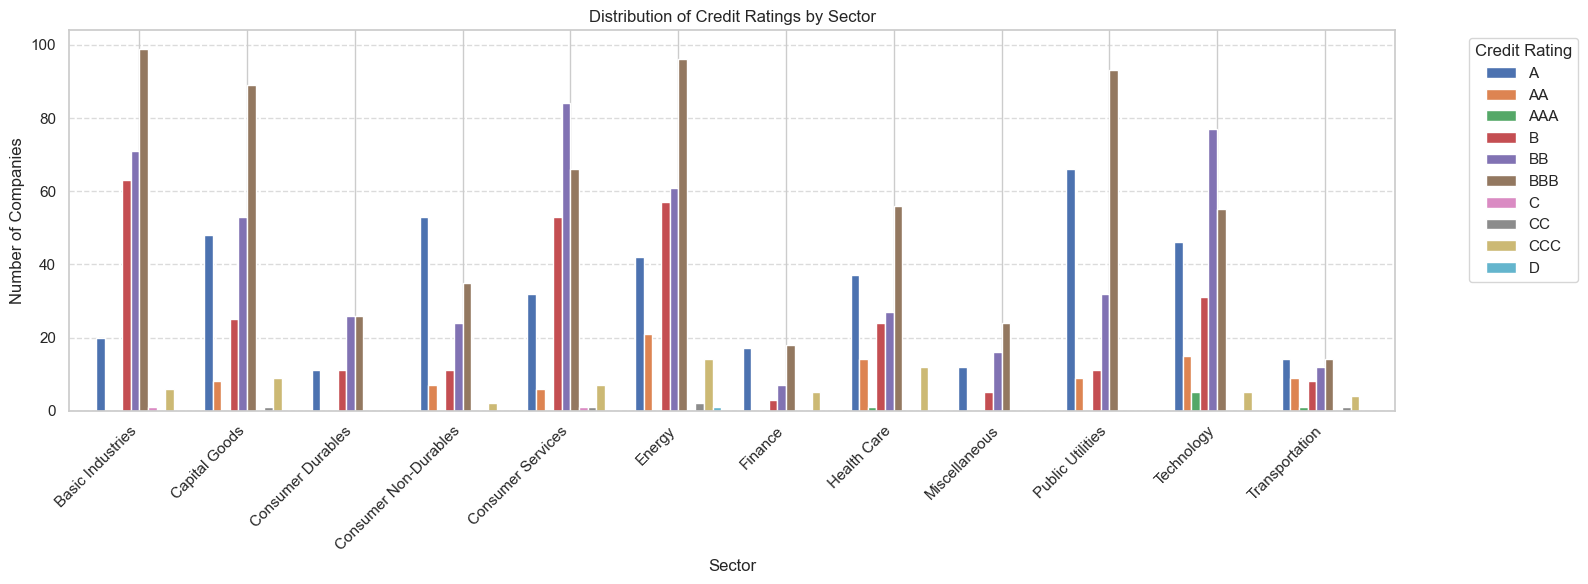

In [27]:
# Step 1: Create a crosstab of Sector vs Rating
sector_rating_ct = pd.crosstab(df_clean['Sector'], df_clean['Rating'])

# Step 2: Plot the grouped bar chart
sector_rating_ct.plot(kind='bar', figsize=(16, 6), width=0.8)

# Step 3: Customize the chart
plt.title('Distribution of Credit Ratings by Sector')
plt.xlabel('Sector')
plt.ylabel('Number of Companies')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Credit Rating', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

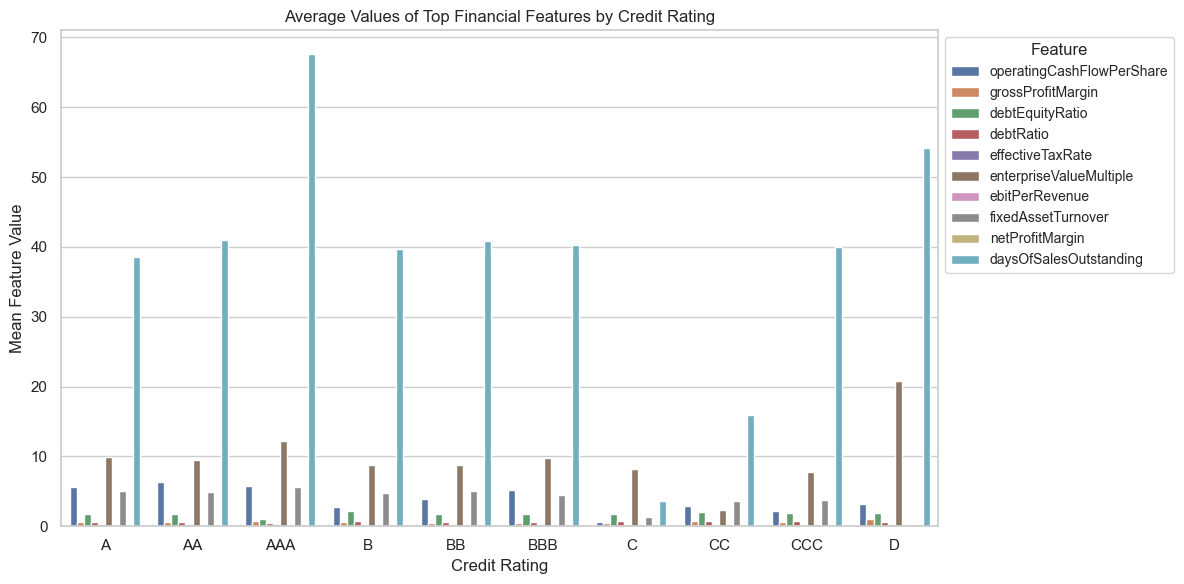

In [28]:
import matplotlib.pyplot as plt
import seaborn as sns


top_features = ['operatingCashFlowPerShare','grossProfitMargin','debtEquityRatio','debtRatio','effectiveTaxRate','enterpriseValueMultiple','ebitPerRevenue','fixedAssetTurnover','fixedAssetTurnover','netProfitMargin','daysOfSalesOutstanding']


rating_feature_means = df_clean.groupby('Rating')[top_features].mean().reset_index()

# Melt for easier plotting
melted = rating_feature_means.melt(id_vars='Rating', var_name='Feature', value_name='Average Value')

# Plot
plt.figure(figsize=(12, 6))
sns.barplot(data=melted, x='Rating', y='Average Value', hue='Feature')
plt.title('Average Values of Top Financial Features by Credit Rating')
plt.ylabel('Mean Feature Value')
plt.xlabel('Credit Rating')
plt.legend(
    title='Feature', 
    bbox_to_anchor=(1, 1), 
    loc='upper left', 
    fontsize='small',
    title_fontsize='medium'
)
plt.tight_layout()
plt.show()


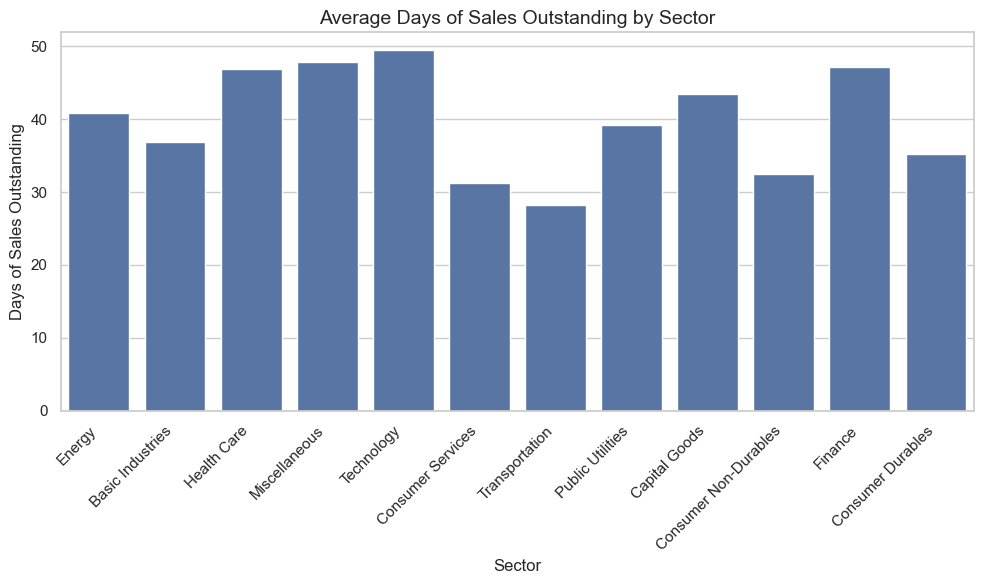

In [29]:
plt.figure(figsize=(10, 6))
sns.barplot(data=df_clean, x='Sector', y='daysOfSalesOutstanding',ci=None)
plt.title("Average Days of Sales Outstanding by Sector", fontsize=14)
plt.xlabel("Sector")
plt.ylabel("Days of Sales Outstanding")
plt.xticks(rotation=45, ha='right')  # Rotate for better readability
plt.tight_layout()
plt.show()